In [ ]:
import pandas as pd
import pickle
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
import pandas as pd

In [ ]:
df=pd.read_csv('job_salary_prediction_dataset.csv')

In [ ]:
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467


# **$EDA$**

In [ ]:
df.shape

(250000, 10)

In [ ]:
df.isnull().sum()

,0
job_title,0
experience_years,0
education_level,0
skills_count,0
industry,0
company_size,0
location,0
remote_work,0
certifications,0
salary,0


In [ ]:
df['skills_count'].unique()

array([ 2, 17,  4, 13,  7, 16, 18, 14, 10,  3,  5,  9,  1, 12, 15,  8, 19,
       11,  6])

In [ ]:
df=df.dropna()

In [ ]:
df.isnull().sum()

,0
job_title,0
experience_years,0
education_level,0
skills_count,0
industry,0
company_size,0
location,0
remote_work,0
certifications,0
salary,0


In [ ]:
df.shape

(250000, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [ ]:
df['skills_count'].unique()

array([ 2, 17,  4, 13,  7, 16, 18, 14, 10,  3,  5,  9,  1, 12, 15,  8, 19,
       11,  6])

In [ ]:
df['skills_count']=df['skills_count'].astype(int)

In [ ]:
df['skills_count'].dtype
df['skills_count'].unique()

array([ 2, 17,  4, 13,  7, 16, 18, 14, 10,  3,  5,  9,  1, 12, 15,  8, 19,
       11,  6])

In [ ]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [ ]:
df['job_title'].unique()

array(['AI Engineer', 'Data Analyst', 'Frontend Developer',
       'Business Analyst', 'Product Manager', 'Backend Developer',
       'Machine Learning Engineer', 'DevOps Engineer',
       'Software Engineer', 'Cybersecurity Analyst', 'Data Scientist',
       'Cloud Engineer'], dtype=object)

In [ ]:
df['remote_work'].unique()

array(['Hybrid', 'No', 'Yes'], dtype=object)

In [ ]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='salary', ylabel='Count'>

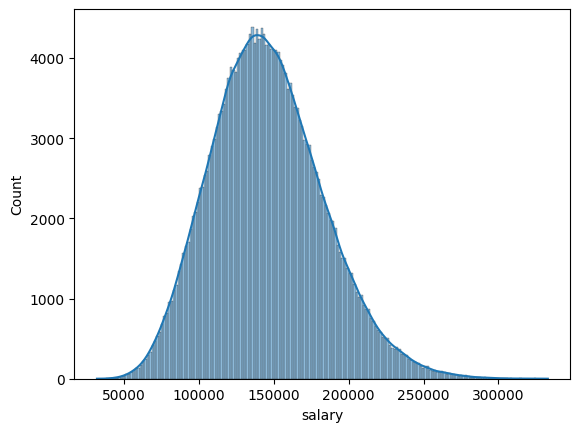

In [ ]:
sns.histplot(df['salary'],kde=True)

<Axes: xlabel='salary'>

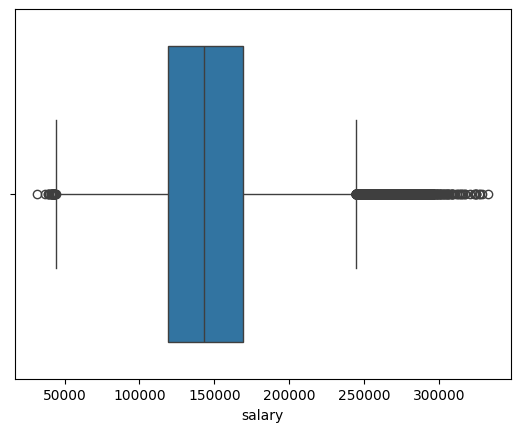

In [ ]:
sns.boxplot(x=df['salary'])

<Axes: xlabel='experience_years'>

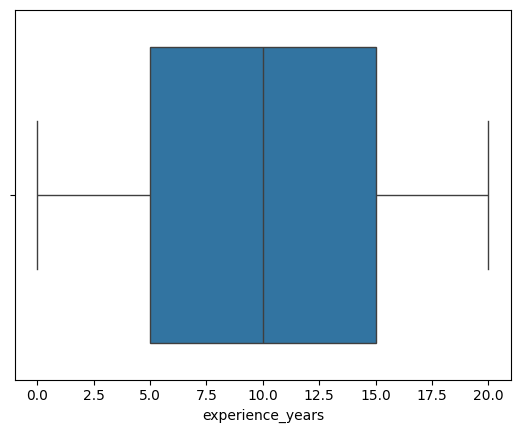

In [ ]:
sns.boxplot(x=df['experience_years'])

In [ ]:
df['education_level'].unique()

array(['Bachelor', 'PhD', 'High School', 'Diploma', 'Master'],
      dtype=object)

<Axes: xlabel='education_level', ylabel='count'>

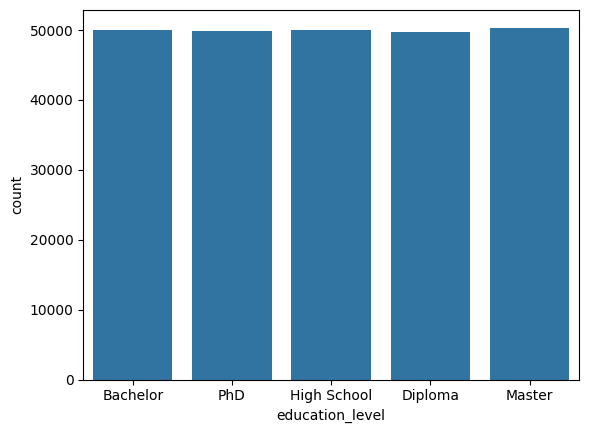

In [ ]:
sns.countplot(x='education_level',data=df)

<Axes: xlabel='count', ylabel='job_title'>

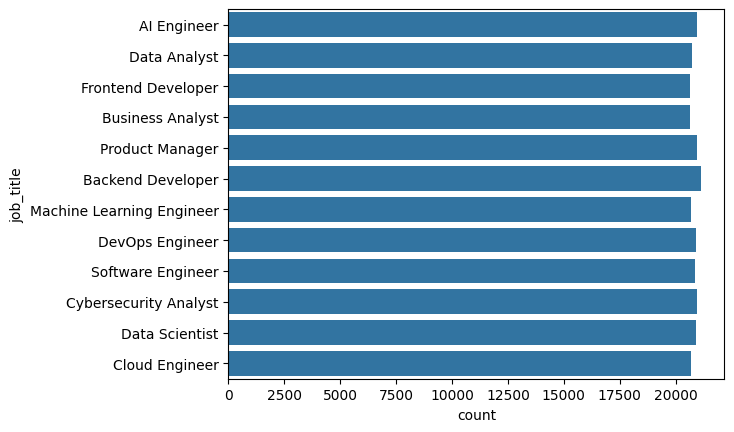

In [ ]:
sns.countplot(df['job_title'])

In [ ]:
df['industry'].unique()

array(['Healthcare', 'Telecom', 'Media', 'Retail', 'Manufacturing',
       'Education', 'Finance', 'Technology', 'Consulting', 'Government'],
      dtype=object)

<Axes: xlabel='count', ylabel='industry'>

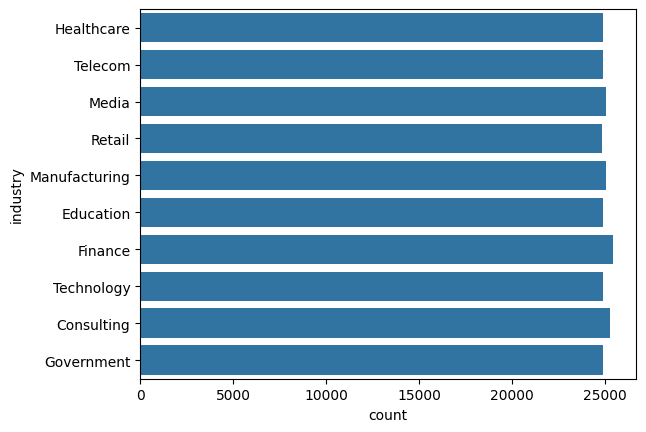

In [ ]:
sns.countplot(df['industry'])

In [ ]:
df['company_size'].unique()

array(['Medium', 'Small', 'Large', 'Enterprise', 'Startup'], dtype=object)

<Axes: xlabel='count', ylabel='company_size'>

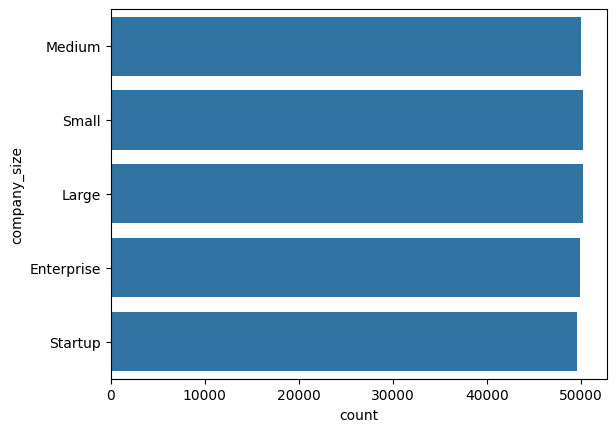

In [ ]:
sns.countplot(df['company_size'])

<Axes: xlabel='salary', ylabel='experience_years'>

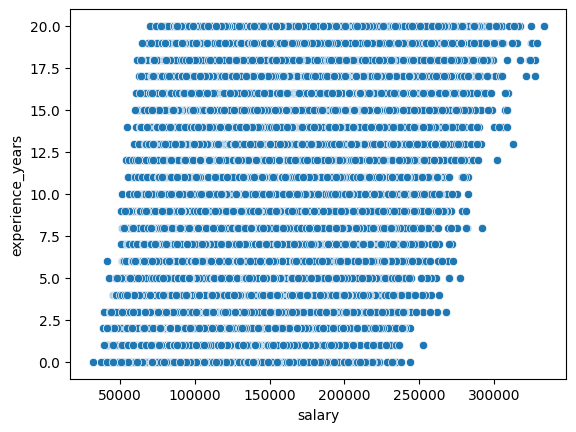

In [ ]:
sns.scatterplot(x='salary',y='experience_years',data=df)

<Axes: xlabel='salary', ylabel='education_level'>

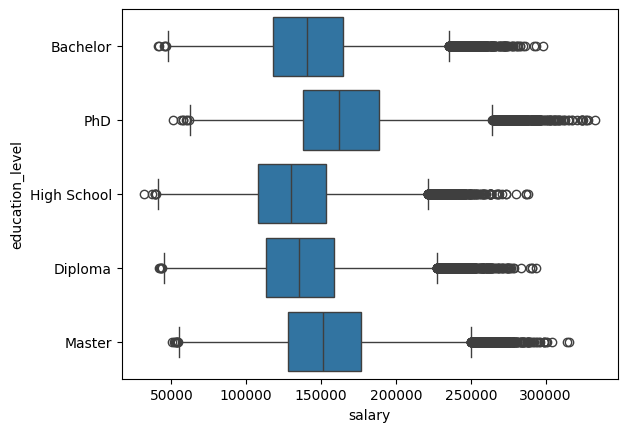

In [ ]:
sns.boxplot(x=df['salary'],y=df['education_level'])

<Axes: xlabel='salary', ylabel='skills_count'>

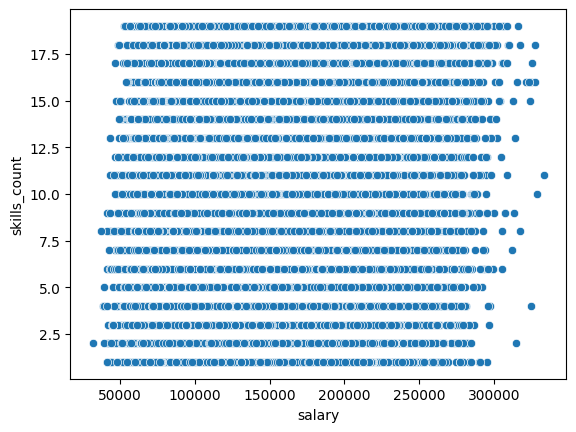

In [ ]:
sns.scatterplot(x='salary',y='skills_count',data=df)

<Axes: xlabel='salary', ylabel='job_title'>

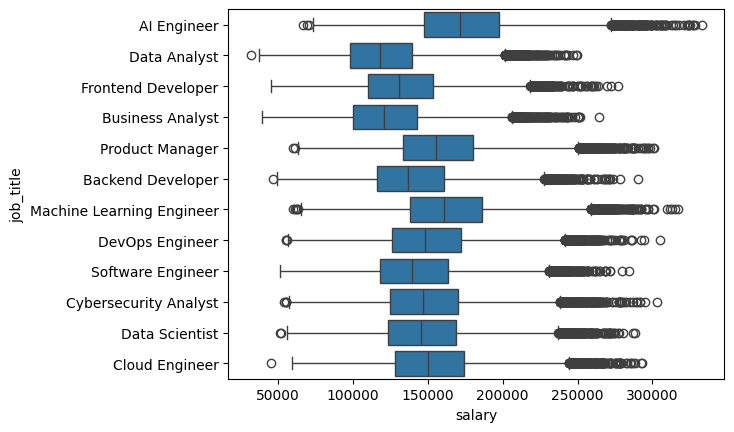

In [ ]:
sns.boxplot(x=df['salary'],y=df['job_title'])

In [ ]:
correlation=df.corr(numeric_only=True)

In [ ]:
print(correlation['salary'].sort_values(ascending=False))

salary              1.000000
experience_years    0.437627
skills_count        0.127300
certifications      0.073819
Name: salary, dtype: float64


<Axes: xlabel='salary', ylabel='remote_work'>

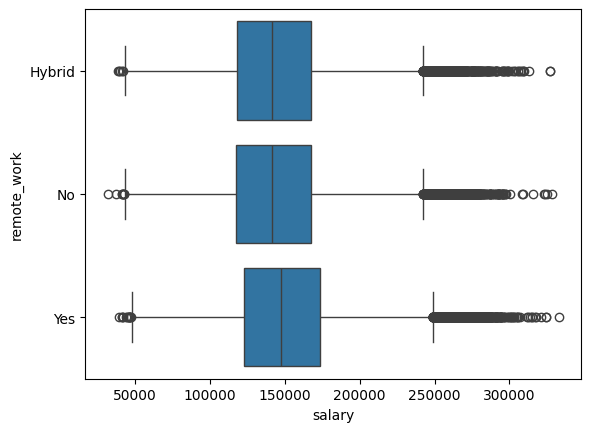

In [ ]:
sns.boxplot(x=df['salary'],y=df['remote_work'])

In [ ]:
df.drop('remote_work',axis=1,inplace=True)

<Axes: xlabel='salary', ylabel='company_size'>

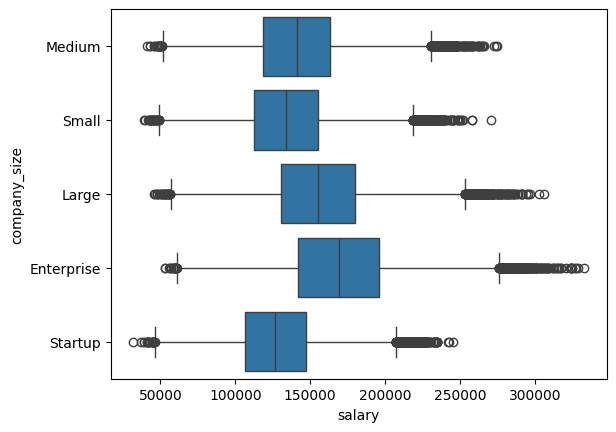

In [ ]:
sns.boxplot(x=df['salary'],y=df['company_size'])

In [ ]:
df['location'].unique()

array(['India', 'Australia', 'Singapore', 'Canada', 'Sweden', 'USA',
       'Netherlands', 'Remote', 'Germany', 'UK'], dtype=object)

<Axes: xlabel='salary', ylabel='location'>

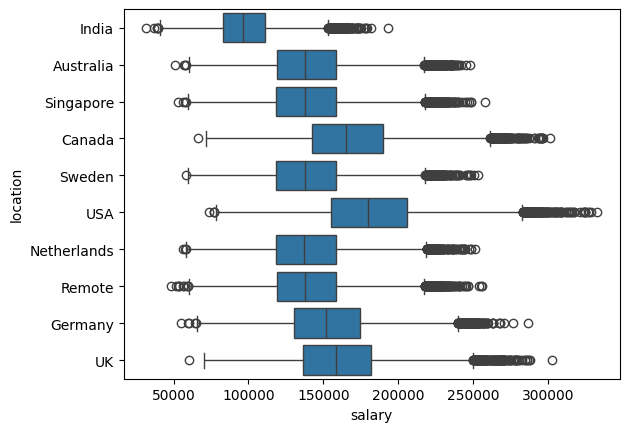

In [ ]:
sns.boxplot(x=df['salary'],y=df['location'])

# **$Encoding$**

In [ ]:
# Do encoding on education_Level

encoder = OrdinalEncoder(categories=[
    ['High School', 'Diploma', 'Bachelor', 'Master', 'PhD'],
    ['Startup', 'Small', 'Medium', 'Large', 'Enterprise']
])

df[['education_level', 'company_size']] = encoder.fit_transform(
    df[['education_level', 'company_size']]
)

In [ ]:
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,certifications,salary
0,AI Engineer,10,2.0,2,Healthcare,2.0,India,2,109413
1,Data Analyst,5,2.0,17,Telecom,1.0,Australia,0,93764
2,Frontend Developer,18,4.0,4,Media,2.0,Singapore,1,148123
3,Business Analyst,19,4.0,13,Retail,2.0,Canada,0,189123
4,Product Manager,15,2.0,7,Manufacturing,3.0,Sweden,0,165069
...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,4.0,2,Telecom,4.0,India,1,127791
249996,Frontend Developer,20,4.0,7,Telecom,0.0,Remote,2,154593
249997,Business Analyst,1,2.0,12,Retail,4.0,India,0,75988
249998,Data Scientist,0,0.0,2,Consulting,1.0,Sweden,5,90467


In [ ]:
df=pd.get_dummies(df,columns=['industry','job_title','location'],drop_first=True,dtype=int)


In [ ]:
df

,experience_years,education_level,skills_count,company_size,certifications,salary,industry_Education,industry_Finance,industry_Government,industry_Healthcare,...,job_title_Software Engineer,location_Canada,location_Germany,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA
0,10,2.0,2,2.0,2,109413,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
1,5,2.0,17,1.0,0,93764,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,18,4.0,4,2.0,1,148123,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,19,4.0,13,2.0,0,189123,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,15,2.0,7,3.0,0,165069,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,17,4.0,2,4.0,1,127791,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
249996,20,4.0,7,0.0,2,154593,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
249997,1,2.0,12,4.0,0,75988,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
249998,0,0.0,2,1.0,5,90467,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


# **$Train Modle$**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import VotingRegressor
from xgboost import XGBRegressor

from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(df.drop('salary',axis=1),df['salary'],test_size=0.2,random_state=42)

In [ ]:
lr=LinearRegression()
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)

print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(root_mean_squared_error(y_test,y_pred))

0.9507338480269403
6409.446719859658
8274.855467447494


In [ ]:
rf=RandomForestRegressor()
rf.fit(X_train,y_train)
y_pred=rf.predict(X_test)

print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(root_mean_squared_error(y_test,y_pred))

0.9604378169983556
5774.408785625001
7415.257205906918


In [ ]:
xgb=XGBRegressor()
xgb.fit(X_train,y_train)
y_pred=xgb.predict(X_test)

print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(root_mean_squared_error(y_test,y_pred))

0.9721666574478149
4944.78857421875
6219.6923828125


In [ ]:
X=df.drop('salary',axis=1)
y=df['salary']


score=cross_val_score(lr,X,y,cv=5)
print(score.mean())

score_rf=cross_val_score(rf,X,y,cv=5)
print(score_rf.mean())

score_xgb=cross_val_score(xgb,X,y,cv=5)
print(score_xgb.mean())


0.9508861630002718
0.9608340473204748
0.9719007134437561


In [ ]:
voting=VotingRegressor(estimators=[('lr',lr),('rf',rf),('xgb',xgb)])
voting.fit(X_train,y_train)

y_pred=voting.predict(X_test)

print(r2_score(y_test,y_pred))

0.9709276103938187


In [ ]:
pickle.dump(encoder, open('ordinal_encoder.pkl', 'wb'))
pickle.dump(X_train.columns.tolist(), open('columns.pkl', 'wb'))

In [ ]:
pickle.dump(xgb, open('model.pkl', 'wb'))

In [ ]:
import os

print(os.path.getsize("model.pkl"))

502698


In [ ]:
print(voting)

VotingRegressor(estimators=[('lr', LinearRegression()),
                            ('rf', RandomForestRegressor()),
                            ('xgb',
                             XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                 